In [1]:
!pip install -U transformers accelerate peft bitsandbytes datasets
!pip install triton==2.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 31.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 49.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 278.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:


import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Load Phi-2 base model in FP16 with device_map
base_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    torch_dtype=torch.float16,
    device_map="auto"
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-2")
tokenizer.pad_token = tokenizer.eos_token

# Prepare model for LoRA fine-tuning (k-bit aware)
model = prepare_model_for_kbit_training(base_model)

# LoRA Configuration (adjust target modules for Phi-2 if needed)
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "dense"]  # phi-2 compatible
)

# Apply LoRA
model = get_peft_model(model, peft_config)

# Optional: Print trainable parameters
model.print_trainable_parameters()


/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

trainable params: 5,242,880 || all params: 2,784,926,720 || trainable%: 0.1883


In [ ]:
### Load and Tokenize Dataset 

import json
from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorForLanguageModeling

# Custom dataset class for chatbot-style instruction tuning
class ChatDataset(Dataset):
    def __init__(self, path, tokenizer, max_length=512):
        self.samples = []
        with open(path, 'r') as f:
            for line in f:
                data = json.loads(line)
                prompt = f"{data['instruction']}\nInput: {data['input']}\nOutput:"
                full_text = prompt + " " + data['output']
                tokenized = tokenizer(
                    full_text,
                    truncation=True,
                    padding='max_length',
                    max_length=max_length,
                    return_tensors='pt'
                )
                tokenized['labels'] = tokenized['input_ids'].clone()
                self.samples.append({k: v.squeeze() for k, v in tokenized.items()})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

# Load your combined dataset
dataset = ChatDataset("/workspace/chatdataset.jsonl", tokenizer)

# Data collator (for padding)
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# DataLoader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collator)

# Confirm size
print("Dataset loaded with", len(dataset), "examples")




Dataset loaded with 56296 examples


In [ ]:
from torch.optim import AdamW
from tqdm import tqdm
import torch

# === Hyperparameters ===
epochs = 3
learning_rate = 2e-4
gradient_accumulation_steps = 4
max_grad_norm = 1.0

# Optimizer for LoRA params only
optimizer = AdamW(model.parameters(), lr=learning_rate)
model.train()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training loop 
for epoch in range(epochs):
    print(f"\n🔁 Epoch {epoch + 1}/{epochs}")
    total_loss = 0.0

    for step, batch in enumerate(tqdm(dataloader)):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / gradient_accumulation_steps
        loss.backward()

        if (step + 1) % gradient_accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * gradient_accumulation_steps

        # Print loss for every 500 steps
        if (step + 1) % 500 == 0:
            avg_loss = total_loss / (step + 1)
            print(f"Step {step + 1}/{len(dataloader)} | Avg Loss: {avg_loss:.4f}")

    epoch_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch + 1} complete | Final Avg Loss: {epoch_loss:.4f}")



🔁 Epoch 1/3


  0%|          | 0/14074 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:271: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
  4%|▎         | 500/14074 [13:36<6:12:15,  1.65s/it]

Step 500/14074 | Avg Loss: 1.3413


  7%|▋         | 1000/14074 [27:15<5:56:29,  1.64s/it]

Step 1000/14074 | Avg Loss: 1.3266


...

Step 13500/14074 | Avg Loss: 1.2238


 99%|█████████▉| 14000/14074 [6:21:29<02:00,  1.63s/it]

Step 14000/14074 | Avg Loss: 1.2250


100%|██████████| 14074/14074 [6:23:30<00:00,  1.63s/it]

Epoch 3 complete | Final Avg Loss: 1.2245


In [ ]:
#Save LoRA-adapted model (not merged yet)
model.save_pretrained("/workspace/phi2-lora-chatbot-checkpoint")

#Save tokenizer
tokenizer.save_pretrained("/workspace/phi2-lora-chatbot-checkpoint")

print(" LoRA checkpoint and tokenizer saved to /workspace/phi2-lora-chatbot-checkpoint")


In [7]:
from transformers import TextStreamer

# Example test prompt (you can change it)
instruction = "Explain what a Python list is and how it works."
input_field = "Lists"
prompt = f"{instruction}\nInput: {input_field}\nOutput:"

# Tokenize and move to device
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate output with the LoRA-tuned model
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode and clean up output
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print("Response:", response)


 Prompt: Explain what a Python list is and how it works.
Input: Lists
Output:
Response: A list in Python is an ordered collection of items, which can be of different types such as numbers, strings, or even other lists. It allows you to store multiple values in one variable and access them by their index. Lists are mutable, meaning that the elements inside them can be changed after they have been created. The syntax for creating a list is to enclose its elements in square brackets [ ] and separate them with commas. For example, my_list = [1, 2, "three"] creates a list containing the integers 1 and 2 followed by the string "three". You can also use the append() method to add new elements to the end of the list.


In [ ]:
#### Example: Generate a Python question based on the topic "Loops"
instruction = "Generate a clear Python programming question."
input_field = "Loops"
prompt = f"{instruction}\nInput: {input_field}\nOutput:"

# Tokenize and move to device
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate output
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode and extract clean result
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print(" Generated Question:", response)


 Prompt: Generate a clear Python programming question.
Input: Loops
Output:
 Generated Question: Use a loop to print the numbers from 1 to 10, but skip the number 5. Print 'Fizz' instead of 5 and 'Buzz' for multiples of 3. For example, FizzBuzz.


In [ ]:
#####Example: Generate a Python question based on the topic "Loops"
instruction = "Generate a clear Python programming question."
input_field = "Variables"
prompt = f"{instruction}\nInput: {input_field}\nOutput:"

# Tokenize and move to device
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate output
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode and extract clean result
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print(" Generated Question:", response)


 Prompt: Generate a clear Python programming question.
Input: Variables
Output:
 Generated Question: Make two variables 'a' and 'b'. Assign the value 10 to 'a' and 20 to 'b'. Print their sum.


In [10]:
# Prompt for code completion
instruction = "Complete the following Python function to return the square of a number."
input_field = "Functions"
prompt = f"""{instruction}\nInput: {input_field}\nOutput:\ndef square(n):"""

# Tokenize and move to device
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate output
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode output and trim it
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print("Code Completion:", response)


 Prompt: Complete the following Python function to return the square of a number.
Input: Functions
Output:
def square(n):
Code Completion: return n * n; 


In [11]:
# Prompt for code completion
instruction = "Complete the function to check if a number is even."
input_field = "Boolean Logic"
prompt = f"""{instruction}\nInput: {input_field}\nOutput:\ndef is_even(n):"""

# Tokenize and move to device
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate output
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode output and trim it
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print("Code Completion:", response)


 Prompt: Complete the function to check if a number is even.
Input: Boolean Logic
Output:
def is_even(n):
Code Completion: return n % 2 == 0  # checks if n is divisible by 2 and returns True or False accordingly


In [ ]:
### Merge LoRA + Save in fp32 .safetensors Format

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Load the base Phi-2 model in fp16 ===
base_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    torch_dtype=torch.float16,
    device_map="auto"
)

#  2. Load the LoRA adapter on top of the base model ===
model = PeftModel.from_pretrained(base_model, "/workspace/phi2-lora-chatbot-checkpoint")

#  3. Merge LoRA weights into the base model ===
model = model.merge_and_unload()  # critical step to collapse into single model

#  4. Convert to fp32 (for CPU) ===
model = model.to(torch.float32)

#  5. Save the merged model in .safetensors format ===
model.save_pretrained(
    "/workspace/phi2-merged-fp32-sft",
    safe_serialization=True  # this saves as .safetensors
)

#  6. Save tokenizer too ===
tokenizer = AutoTokenizer.from_pretrained("/workspace/phi2-lora-chatbot-checkpoint")
tokenizer.save_pretrained("/workspace/phi2-merged-fp32-sft")

print("Merged model saved at /workspace/phi2-merged-fp32-sft (fp32 + .safetensors)")




Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged model saved at /workspace/phi2-merged-fp32-sft (fp32 + .safetensors)


In [ ]:
##### Test the Merged Model in RunPod (GPU)

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

#  1. Load merged model from .safetensors in fp32 (RunPod GPU OK) 
model = AutoModelForCausalLM.from_pretrained(
    "/workspace/phi2-merged-fp32-sft",
    torch_dtype=torch.float32,
    device_map="auto"
)

#  2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("/workspace/phi2-merged-fp32-sft")
tokenizer.pad_token = tokenizer.eos_token

# 3. Define prompt 
instruction = "Find and fix the error in this Python code:\n\nfor i in range(5)\n    print(i)"
input_field = "Loops"
prompt = f"{instruction}\nInput: {input_field}\nOutput:"

#  4. Tokenize 
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# 5. Generate response
model.eval()
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

# 6. Decode and print
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
response = decoded[len(prompt):].strip().split("\n")[0]

print(" Prompt:", prompt)
print(" Response:", response)



Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

 Prompt: Find and fix the error in this Python code:

for i in range(5)
    print(i)
Input: Loops
Output:
 Response: ❌ Error: Missing colon at end of `for` statement.


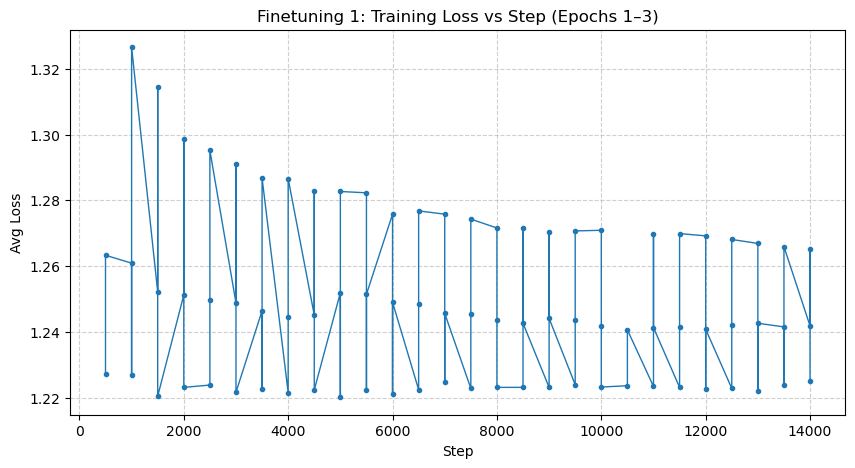

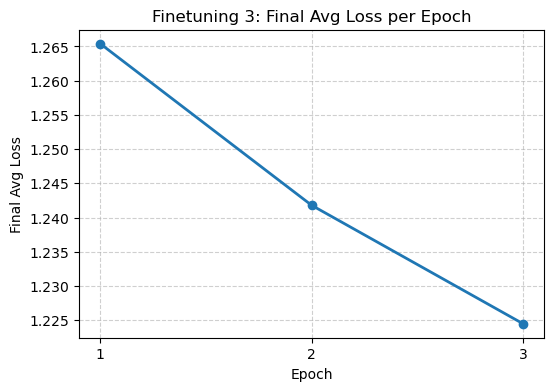

Step-level losses (sample):


,step,avg_loss
54,500,1.2272
26,500,1.2633
27,1000,1.2609
55,1000,1.2268
0,1000,1.3266
28,1500,1.2522
1,1500,1.3146
56,1500,1.2204
29,2000,1.2512
2,2000,1.2986


Epoch summary:


,epoch,final_avg_loss
0,1,1.2654
1,2,1.2418
2,3,1.2245


In [7]:
import re
import matplotlib.pyplot as plt
import pandas as pd

# === Full training log pasted ===
log_text = """
Step 1000/14074 | Avg Loss: 1.3266
Step 1500/14074 | Avg Loss: 1.3146
Step 2000/14074 | Avg Loss: 1.2986
Step 2500/14074 | Avg Loss: 1.2952
Step 3000/14074 | Avg Loss: 1.2912
Step 3500/14074 | Avg Loss: 1.2868
Step 4000/14074 | Avg Loss: 1.2866
Step 4500/14074 | Avg Loss: 1.2829
Step 5000/14074 | Avg Loss: 1.2827
Step 5500/14074 | Avg Loss: 1.2823
Step 6000/14074 | Avg Loss: 1.2758
Step 6500/14074 | Avg Loss: 1.2768
Step 7000/14074 | Avg Loss: 1.2758
Step 7500/14074 | Avg Loss: 1.2743
Step 8000/14074 | Avg Loss: 1.2716
Step 8500/14074 | Avg Loss: 1.2716
Step 9000/14074 | Avg Loss: 1.2704
Step 9500/14074 | Avg Loss: 1.2707
Step 10000/14074 | Avg Loss: 1.2709
Step 11000/14074 | Avg Loss: 1.2699
Step 11500/14074 | Avg Loss: 1.2699
Step 12000/14074 | Avg Loss: 1.2692
Step 12500/14074 | Avg Loss: 1.2681
Step 13000/14074 | Avg Loss: 1.2669
Step 13500/14074 | Avg Loss: 1.2659
Step 14000/14074 | Avg Loss: 1.2652
Epoch 1 complete | Final Avg Loss: 1.2654

Step 500/14074 | Avg Loss: 1.2633
Step 1000/14074 | Avg Loss: 1.2609
Step 1500/14074 | Avg Loss: 1.2522
Step 2000/14074 | Avg Loss: 1.2512
Step 2500/14074 | Avg Loss: 1.2498
Step 3000/14074 | Avg Loss: 1.2488
Step 3500/14074 | Avg Loss: 1.2464
Step 4000/14074 | Avg Loss: 1.2444
Step 4500/14074 | Avg Loss: 1.2451
Step 5000/14074 | Avg Loss: 1.2519
Step 5500/14074 | Avg Loss: 1.2514
Step 6000/14074 | Avg Loss: 1.2490
Step 6500/14074 | Avg Loss: 1.2486
Step 7000/14074 | Avg Loss: 1.2456
Step 7500/14074 | Avg Loss: 1.2454
Step 8000/14074 | Avg Loss: 1.2435
Step 8500/14074 | Avg Loss: 1.2426
Step 9000/14074 | Avg Loss: 1.2441
Step 9500/14074 | Avg Loss: 1.2436
Step 10000/14074 | Avg Loss: 1.2417
Step 10500/14074 | Avg Loss: 1.2406
Step 11000/14074 | Avg Loss: 1.2413
Step 11500/14074 | Avg Loss: 1.2414
Step 12000/14074 | Avg Loss: 1.2408
Step 12500/14074 | Avg Loss: 1.2422
Step 13000/14074 | Avg Loss: 1.2426
Step 13500/14074 | Avg Loss: 1.2415
Step 14000/14074 | Avg Loss: 1.2418
Epoch 2 complete | Final Avg Loss: 1.2418

Step 500/14074 | Avg Loss: 1.2272
Step 1000/14074 | Avg Loss: 1.2268
Step 1500/14074 | Avg Loss: 1.2204
Step 2000/14074 | Avg Loss: 1.2231
Step 2500/14074 | Avg Loss: 1.2238
Step 3000/14074 | Avg Loss: 1.2216
Step 3500/14074 | Avg Loss: 1.2226
Step 4000/14074 | Avg Loss: 1.2215
Step 4500/14074 | Avg Loss: 1.2223
Step 5000/14074 | Avg Loss: 1.2201
Step 5500/14074 | Avg Loss: 1.2223
Step 6000/14074 | Avg Loss: 1.2210
Step 6500/14074 | Avg Loss: 1.2224
Step 7000/14074 | Avg Loss: 1.2248
Step 7500/14074 | Avg Loss: 1.2228
Step 8000/14074 | Avg Loss: 1.2231
Step 8500/14074 | Avg Loss: 1.2231
Step 9000/14074 | Avg Loss: 1.2231
Step 9500/14074 | Avg Loss: 1.2239
Step 10000/14074 | Avg Loss: 1.2232
Step 10500/14074 | Avg Loss: 1.2236
Step 11000/14074 | Avg Loss: 1.2234
Step 11500/14074 | Avg Loss: 1.2231
Step 12000/14074 | Avg Loss: 1.2227
Step 12500/14074 | Avg Loss: 1.2228
Step 13000/14074 | Avg Loss: 1.2221
Step 13500/14074 | Avg Loss: 1.2238
Step 14000/14074 | Avg Loss: 1.2250
Epoch 3 complete | Final Avg Loss: 1.2245
"""

# --- Parse step-level logs ---
step_pattern = re.compile(r"Step\s+(\d+)/\d+\s*\|\s*Avg Loss:\s*([0-9.]+)")
steps, losses = [], []
for m in step_pattern.finditer(log_text):
    steps.append(int(m.group(1)))
    losses.append(float(m.group(2)))

# --- Parse epoch-level summaries ---
epoch_pattern = re.compile(r"Epoch\s+(\d+)\s+complete\s*\|\s*Final Avg Loss:\s*([0-9.]+)")
epochs, epoch_losses = [], []
for m in epoch_pattern.finditer(log_text):
    epochs.append(int(m.group(1)))
    epoch_losses.append(float(m.group(2)))

# --- Convert to DataFrames ---
df_steps = pd.DataFrame({"step": steps, "avg_loss": losses}).sort_values("step")
df_epochs = pd.DataFrame({"epoch": epochs, "final_avg_loss": epoch_losses}).sort_values("epoch")

# --- Plot 1: Training loss vs step ---
plt.figure(figsize=(10,5))
plt.plot(df_steps["step"], df_steps["avg_loss"], marker=".", linewidth=1)
plt.title("Finetuning 1: Training Loss vs Step (Epochs 1–3)")
plt.xlabel("Step")
plt.ylabel("Avg Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Plot 2: Final avg loss per epoch ---
plt.figure(figsize=(6,4))
plt.plot(df_epochs["epoch"], df_epochs["final_avg_loss"], marker="o", linewidth=2)
plt.title("Finetuning 3: Final Avg Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Final Avg Loss")
plt.xticks(df_epochs["epoch"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Display DataFrames inline ---
print("Step-level losses (sample):")
display(df_steps.head(10))
print("Epoch summary:")
display(df_epochs)
